In [20]:
import os
import sys
from pathlib import Path

project_root = Path.cwd()
if project_root.name != "TMDB":
    candidate = project_root / "TMDB"
    if candidate.exists():
        project_root = candidate

os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Working directory: {Path.cwd()}")

Working directory: c:\Users\mbarn\amalitechprojects\TMDB


In [21]:
import pandas as pd
from IPython.display import Image, display

from api.api import TMDB
from ingestion.fetch_movie import fetch_movie, movie_ids
from processing.clean_movies import clean_movies
from analysis.kpi_analysis import (
    compute_profit,
    filter_votes,
    top_revenue,
    top_budget,
    top_profit,
    top_roi,
    lowest_budget,
    top_voted,
    highest_rated,
    lowest_rated,
    most_popular,
    search_movies,
    franchise_vs_standalone,
    top_franchises,
)
from visualization.plots import (
    plot_roi_by_genre,
    plot_revenue_vs_budget,
    plot_popularity_vs_rating,
    plot_yearly_revenue_trends,
    plot_franchise_vs_standalone,
)
from index import run_pipeline

## 2) Live API Client Calls


In [22]:
from api.api import TMDB
tmdb = TMDB()
sample_movie_id = 299534
sample_batch_ids = movie_ids[:5]

async with __import__('httpx').AsyncClient(timeout=10.0, http2=True) as client:
    one_movie = await tmdb.get_movie_with_credits_async(client, sample_movie_id)

batch_async_movies = await tmdb.get_movies_batch_async(sample_batch_ids, max_concurrent=5)
batch_sync_movies = tmdb.get_movies_batch(sample_batch_ids, max_concurrent=5)

print("Single movie keys:", sorted(one_movie.keys())[:10] if one_movie else "None")
print("Async batch size:", len(batch_async_movies))
print("Sync batch size:", len(batch_sync_movies))

INFO:httpx:HTTP Request: GET https://api.themoviedb.org/3/movie/299534?api_key=8b3fa69ac4f1756c2aaf5fac9abffa3f&language=en-US&append_to_response=credits "HTTP/2 200 OK"
INFO:api.api:Fetched movie 299534 with credits
INFO:httpx:HTTP Request: GET https://api.themoviedb.org/3/movie/0?api_key=8b3fa69ac4f1756c2aaf5fac9abffa3f&language=en-US&append_to_response=credits "HTTP/2 404 Not Found"
INFO:httpx:HTTP Request: GET https://api.themoviedb.org/3/movie/299534?api_key=8b3fa69ac4f1756c2aaf5fac9abffa3f&language=en-US&append_to_response=credits "HTTP/2 200 OK"
INFO:api.api:Fetched movie 299534 with credits
INFO:httpx:HTTP Request: GET https://api.themoviedb.org/3/movie/140607?api_key=8b3fa69ac4f1756c2aaf5fac9abffa3f&language=en-US&append_to_response=credits "HTTP/2 200 OK"
INFO:httpx:HTTP Request: GET https://api.themoviedb.org/3/movie/19995?api_key=8b3fa69ac4f1756c2aaf5fac9abffa3f&language=en-US&append_to_response=credits "HTTP/2 200 OK"
INFO:api.api:Fetched movie 140607 with credits
INFO:api

Single movie keys: ['adult', 'backdrop_path', 'belongs_to_collection', 'budget', 'credits', 'genres', 'homepage', 'id', 'imdb_id', 'origin_country']
Async batch size: 4
Sync batch size: 4


## 3) Data Pipeline Stages


In [23]:
raw_df = await fetch_movie()
clean_df = clean_movies(raw_df)
kpi_df = compute_profit(clean_df)

print("raw_df shape:", raw_df.shape)
print("clean_df shape:", clean_df.shape)
print("kpi_df shape:", kpi_df.shape)
kpi_df.head(3)

INFO:httpx:HTTP Request: GET https://api.themoviedb.org/3/movie/0?api_key=8b3fa69ac4f1756c2aaf5fac9abffa3f&language=en-US&append_to_response=credits "HTTP/2 404 Not Found"
INFO:httpx:HTTP Request: GET https://api.themoviedb.org/3/movie/299534?api_key=8b3fa69ac4f1756c2aaf5fac9abffa3f&language=en-US&append_to_response=credits "HTTP/2 200 OK"
INFO:httpx:HTTP Request: GET https://api.themoviedb.org/3/movie/19995?api_key=8b3fa69ac4f1756c2aaf5fac9abffa3f&language=en-US&append_to_response=credits "HTTP/2 200 OK"
INFO:api.api:Fetched movie 299534 with credits
INFO:httpx:HTTP Request: GET https://api.themoviedb.org/3/movie/140607?api_key=8b3fa69ac4f1756c2aaf5fac9abffa3f&language=en-US&append_to_response=credits "HTTP/2 200 OK"
INFO:httpx:HTTP Request: GET https://api.themoviedb.org/3/movie/299536?api_key=8b3fa69ac4f1756c2aaf5fac9abffa3f&language=en-US&append_to_response=credits "HTTP/2 200 OK"
INFO:api.api:Fetched movie 140607 with credits
INFO:api.api:Fetched movie 19995 with credits
INFO:http

genres
Action|Adventure|Science Fiction             3
Adventure|Action|Science Fiction             3
Action|Adventure|Science Fiction|Thriller    2
Adventure|Science Fiction|Action             1
Drama|Romance                                1
Name: count, dtype: int64
raw_df shape: (18, 27)
clean_df shape: (18, 22)
kpi_df shape: (18, 24)


,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Adventure|Science Fiction|Action,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,181,After the devastating events of Avengers: Infi...,English|日本語|,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,104,Anthony Russo,610,2443.439100,6.863593
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,Dune Entertainment|Lightstorm Entertainment|20...,...,162,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,67,James Cameron,996,2686.706026,11.336312
2,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Adventure|Action|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Lucasfilm Ltd.|Bad Robot,...,136,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,265,1823.223624,7.441729


## 4) Analysis Helpers


In [24]:
voted_df = filter_votes(kpi_df, min_votes=100)

analysis_outputs = {
    "filter_votes": voted_df.head(5),
    "top_revenue": top_revenue(kpi_df, top_n=5),
    "top_budget": top_budget(kpi_df, top_n=5),
    "top_profit": top_profit(kpi_df, top_n=5),
    "top_roi": top_roi(kpi_df, top_n=5),
    "lowest_budget": lowest_budget(kpi_df, top_n=5),
    "top_voted": top_voted(kpi_df, top_n=5),
    "highest_rated": highest_rated(kpi_df, top_n=5),
    "lowest_rated": lowest_rated(kpi_df, top_n=5),
    "most_popular": most_popular(kpi_df, top_n=5),
    "search_movies": search_movies(kpi_df, genre="Action", sort_by="vote_average", ascending=False).head(5),
    "search_movies Bruce Willis": search_movies(kpi_df, genre=["Science Fiction", "Action"], actors="Bruce Willis", sort_by="vote_average", ascending=False),
    # "search_movies Tarantino": search_movies(kpi_df, director="Quentin Tarantino", sort_by="profit_musd", ascending=False).head(5),
    # "franchise_vs_standalone": franchise_vs_standalone(kpi_df),
    # "top_franchises": top_franchises(kpi_df, top_n=5),
}

for name, frame in analysis_outputs.items():
    print(f"\n=== {name} ===")
    display(frame)


=== filter_votes ===


,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Adventure|Science Fiction|Action,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,181,After the devastating events of Avengers: Infi...,English|日本語|,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,104,Anthony Russo,610,2443.439100,6.863593
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,Dune Entertainment|Lightstorm Entertainment|20...,...,162,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,67,James Cameron,996,2686.706026,11.336312
2,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Adventure|Action|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Lucasfilm Ltd.|Bad Robot,...,136,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,265,1823.223624,7.441729
3,299536,Avengers: Infinity War,Destiny arrives all the same.,2018-04-25,Adventure|Action|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,149,As the Avengers and their allies have continue...,English|,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,69,Joe Russo,738,1752.415039,5.841383
4,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama|Romance,NaN,en,200.0,2264.162353,Paramount Pictures|20th Century Fox|Lightstorm...,...,194,101-year-old Rose DeWitt Bukater tells the sto...,English|Français|Deutsch|svenska|Italiano|Pусский,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,116,James Cameron,264,2064.162353,10.320812



=== top_revenue ===


,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,Dune Entertainment|Lightstorm Entertainment|20...,...,162,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,67,James Cameron,996,2686.706026,11.336312
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Adventure|Science Fiction|Action,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,181,After the devastating events of Avengers: Infi...,English|日本語|,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,104,Anthony Russo,610,2443.439100,6.863593
4,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama|Romance,NaN,en,200.0,2264.162353,Paramount Pictures|20th Century Fox|Lightstorm...,...,194,101-year-old Rose DeWitt Bukater tells the sto...,English|Français|Deutsch|svenska|Italiano|Pусский,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,116,James Cameron,264,2064.162353,10.320812
2,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Adventure|Action|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Lucasfilm Ltd.|Bad Robot,...,136,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,265,1823.223624,7.441729
3,299536,Avengers: Infinity War,Destiny arrives all the same.,2018-04-25,Adventure|Action|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,149,As the Avengers and their allies have continue...,English|,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,69,Joe Russo,738,1752.415039,5.841383



=== top_budget ===


...

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi
7,24428,The Avengers,Some assembly required.,2012-04-25,Science Fiction|Action|Adventure,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,143,When an unexpected enemy emerges and threatens...,English|हिन्दी|Pусский,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,642,1298.815515,5.903707
3,299536,Avengers: Infinity War,Destiny arrives all the same.,2018-04-25,Adventure|Action|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,149,As the Avengers and their allies have continue...,English|,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,69,Joe Russo,738,1752.415039,5.841383
4,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama|Romance,NaN,en,200.0,2264.162353,Paramount Pictures|20th Century Fox|Lightstorm...,...,194,101-year-old Rose DeWitt Bukater tells the sto...,English|Français|Deutsch|svenska|Italiano|Pусский,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,116,James Cameron,264,2064.162353,10.320812
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,Dune Entertainment|Lightstorm Entertainment|20...,...,162,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,67,James Cameron,996,2686.706026,11.336312
12,181808,Star Wars: The Last Jedi,Let the past die.,2017-12-13,Adventure|Action|Science Fiction,Star Wars Collection,en,300.0,1332.698830,Lucasfilm Ltd.,...,152,Rey develops her newly discovered abilities wi...,English,/kOVEVeg59E0wsnXmF9nrh6OmWII.jpg,Mark Hamill|Carrie Fisher|Adam Driver|Daisy Ri...,111,Rian Johnson,199,1032.698830,3.442329



=== search_movies ===


,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Adventure|Science Fiction|Action,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,181,After the devastating events of Avengers: Infi...,English|日本語|,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,104,Anthony Russo,610,2443.439100,6.863593
3,299536,Avengers: Infinity War,Destiny arrives all the same.,2018-04-25,Adventure|Action|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,149,As the Avengers and their allies have continue...,English|,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,69,Joe Russo,738,1752.415039,5.841383
7,24428,The Avengers,Some assembly required.,2012-04-25,Science Fiction|Action|Adventure,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,143,When an unexpected enemy emerges and threatens...,English|हिन्दी|Pусский,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,642,1298.815515,5.903707
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,Dune Entertainment|Lightstorm Entertainment|20...,...,162,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,67,James Cameron,996,2686.706026,11.336312
17,260513,Incredibles 2,"It's been too long, dahlings.",2018-06-14,Action|Adventure|Animation|Family,The Incredibles Collection,en,200.0,1243.225667,Pixar,...,118,Elastigirl springs into action to save the day...,English,/9lFKBtaVIhP7E2Pk0IY1CwTKTMZ.jpg,Craig T. Nelson|Holly Hunter|Sarah Vowell|Huck...,84,Brad Bird,260,1043.225667,5.216128



=== search_movies Bruce Willis ===


,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi


## 5) Visualization Outputs



Generated: reports/figures/roi_by_genre.png


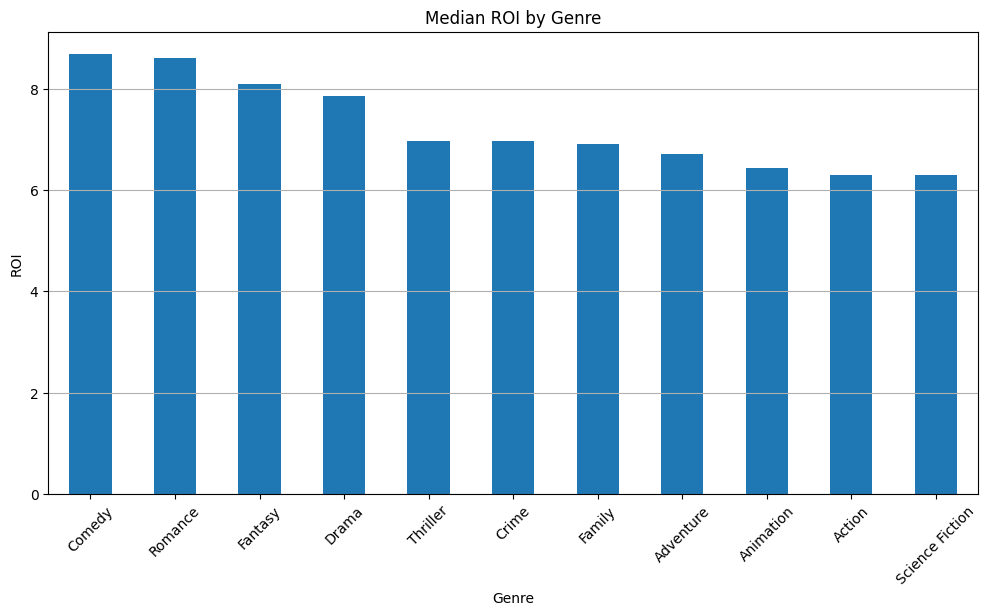


Generated: reports/figures/revenue_vs_budget.png


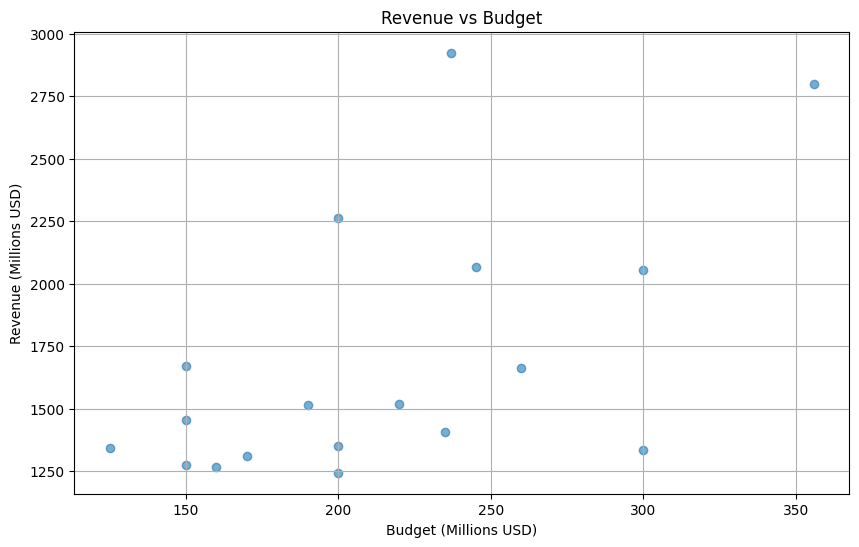


Generated: reports/figures/popularity_vs_rating.png


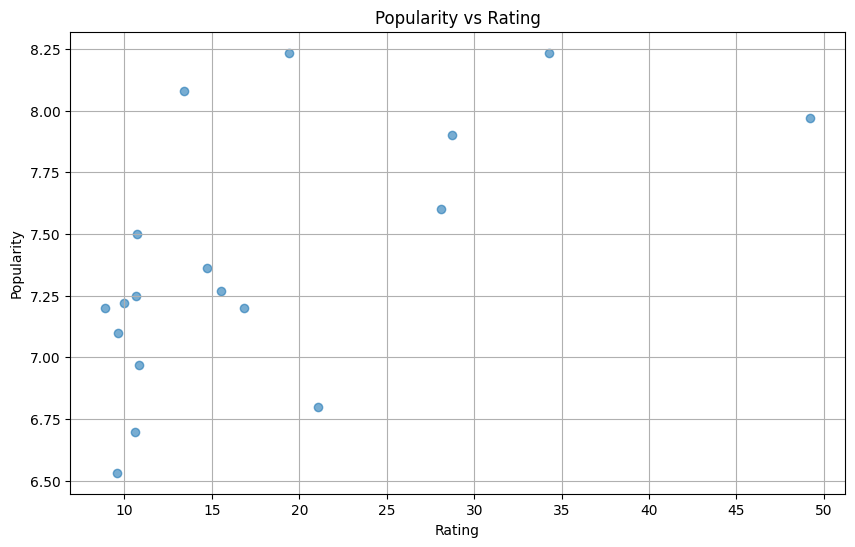


Generated: reports/figures/yearly_revenue_trends.png


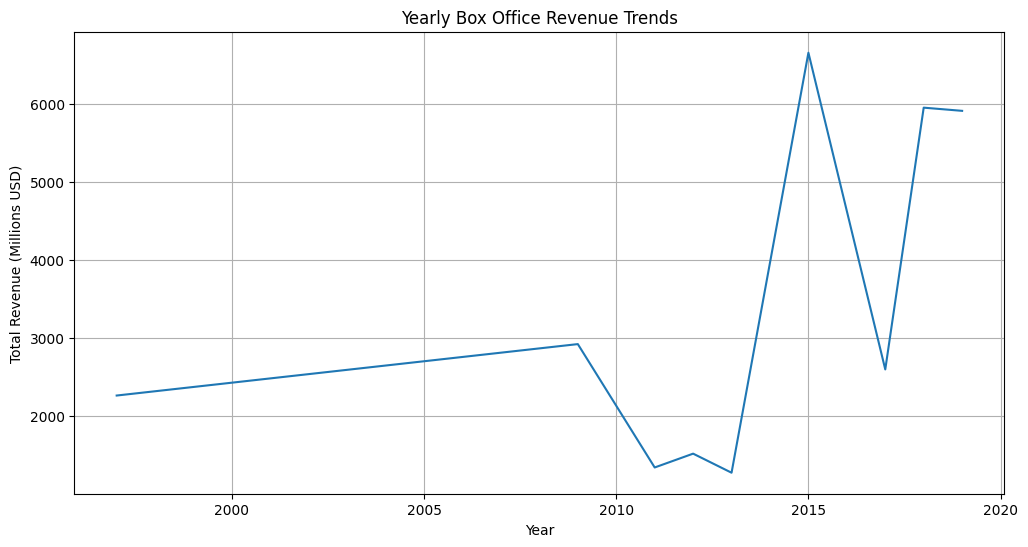


Generated: reports/figures/franchise_vs_standalone.png


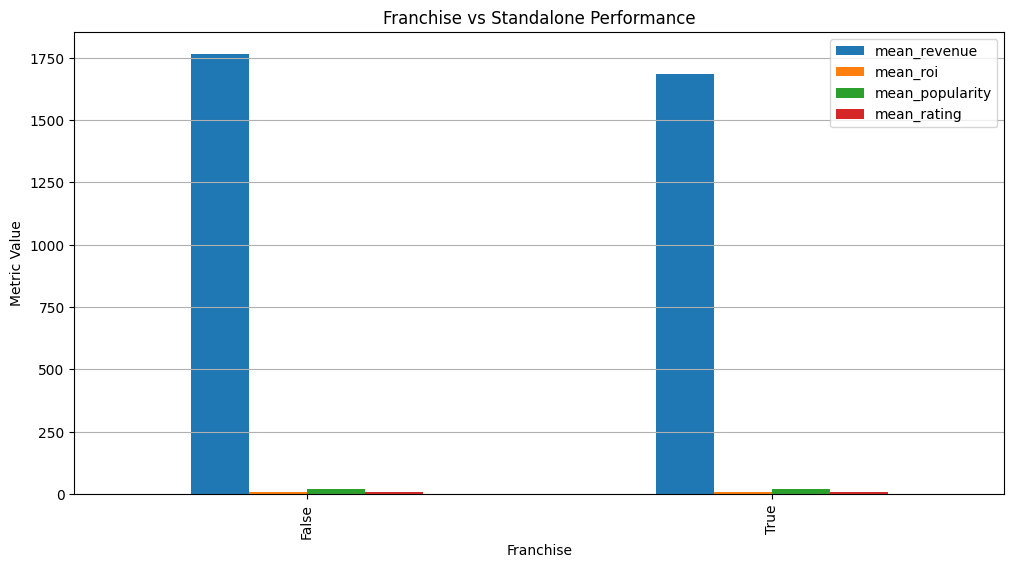

In [25]:
plot_roi_by_genre(kpi_df)
plot_revenue_vs_budget(kpi_df)
plot_popularity_vs_rating(kpi_df)
plot_yearly_revenue_trends(kpi_df)
plot_franchise_vs_standalone(kpi_df)

figure_files = [
    "reports/figures/roi_by_genre.png",
    "reports/figures/revenue_vs_budget.png",
    "reports/figures/popularity_vs_rating.png",
    "reports/figures/yearly_revenue_trends.png",
    "reports/figures/franchise_vs_standalone.png",
]

for fig in figure_files:
    print(f"\nGenerated: {fig}")
    display(Image(filename=fig))